# 01 â€” Exploratory Data Analysis

First look at the Lending Club data. Goal: understand the shape of the problem, where missing data is, how each feature relates to default.

## Setup and load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('../data/loan.csv', low_memory=False)
print(f'{len(df):,} rows, {len(df.columns)} columns')


2,260,701 rows, 151 columns


In [2]:
# Parse text-encoded numerics
df['int_rate'] = df['int_rate'].astype(str).str.rstrip('%').replace('nan', np.nan).astype(float)
df['revol_util'] = df['revol_util'].astype(str).str.rstrip('%').replace('nan', np.nan).astype(float)
df['term'] = df['term'].astype(str).str.strip().str.split().str[0].replace('nan', np.nan).astype(float)


## Schema and missing data

In [3]:
print('Dtype counts:')
print(df.dtypes.value_counts())

missing = df.isna().sum().sort_values(ascending=False)
heavy_missing = missing[missing > len(df) * 0.5]
print(f'\n{len(heavy_missing)} columns are >50% missing')
print(heavy_missing.head(20))


Dtype counts:
float64    114
object      37
Name: count, dtype: int64



44 columns are >50% missing
member_id                                     2260701
orig_projected_additional_accrued_interest    2252050
hardship_reason                               2249784
hardship_payoff_balance_amount                2249784
hardship_last_payment_amount                  2249784
payment_plan_start_date                       2249784
hardship_type                                 2249784
hardship_status                               2249784
hardship_start_date                           2249784
deferral_term                                 2249784
hardship_amount                               2249784
hardship_dpd                                  2249784
hardship_loan_status                          2249784
hardship_length                               2249784
hardship_end_date                             2249784
settlement_status                             2226455
debt_settlement_flag_date                     2226455
settlement_term                               2226455

**Observations**

- 2.26M rows, 151 columns. 44 of those are >50% missing — mostly `hardship_*` and `settlement_*` fields, which only get populated when a loan goes into trouble. These are leakage and were correctly excluded from train.py.
- After dropping the heavily-missing columns, the usable feature pool is much smaller than 151 implies. Notebook 04 will look at what else is worth pulling in beyond the 20 we already use.


## Target distribution

In [4]:
print('All loan statuses:')
print(df['loan_status'].value_counts(dropna=False))

settled = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
settled['target'] = (settled['loan_status'] == 'Charged Off').astype(int)
print(f'\n{len(settled):,} settled loans, default rate {settled["target"].mean():.1%}')


All loan statuses:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64



1,345,310 settled loans, default rate 20.0%


**Observations**

- 1.35M settled loans, 20% default rate. Imbalanced but not severe — stratified train/test split (which train.py does) is enough. Class-weight balancing might help slightly; worth a try in notebook 03.
- 878K loans were excluded because they're still `Current` or `In Grace Period` — outcome unknown. This introduces a mild survivorship bias: we're training on loans whose outcome we already know, which skews older (issued long enough ago to settle). For a real production model you'd revisit this with vintage analysis.
- The 40 `Default` rows could legitimately be folded into `Charged Off` if we cared about every example, but at this scale it doesn't matter.


## Numeric feature summary

In [5]:
FEATURES_NUMERIC = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'delinq_2yrs', 'fico_range_low', 'inq_last_6mths', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
]

print(settled[FEATURES_NUMERIC].describe().T[['mean', 'std', 'min', '50%', 'max']])


                        mean           std     min       50%          max
loan_amnt       14419.972014   8717.050787  500.00  12000.00     40000.00
int_rate           13.239619      4.768716    5.31     12.74        30.99
installment       438.075533    261.512604    4.93    375.43      1719.83
annual_inc      76247.636414  69925.098427    0.00  65000.00  10999200.00
dti                18.282667     11.160446   -1.00     17.61       999.00
delinq_2yrs         0.317794      0.877992    0.00      0.00        39.00
fico_range_low    696.185039     31.852512  625.00    690.00       845.00
inq_last_6mths      0.655081      0.937774    0.00      0.00         8.00
open_acc           11.593520      5.473789    0.00     11.00        90.00
pub_rec             0.215276      0.601865    0.00      0.00        86.00
revol_bal       16248.114860  22328.168731    0.00  11134.00   2904836.00
revol_util         51.810022     24.521072    0.00     52.20       892.30
total_acc          24.980839     11.99

## Numeric feature distributions

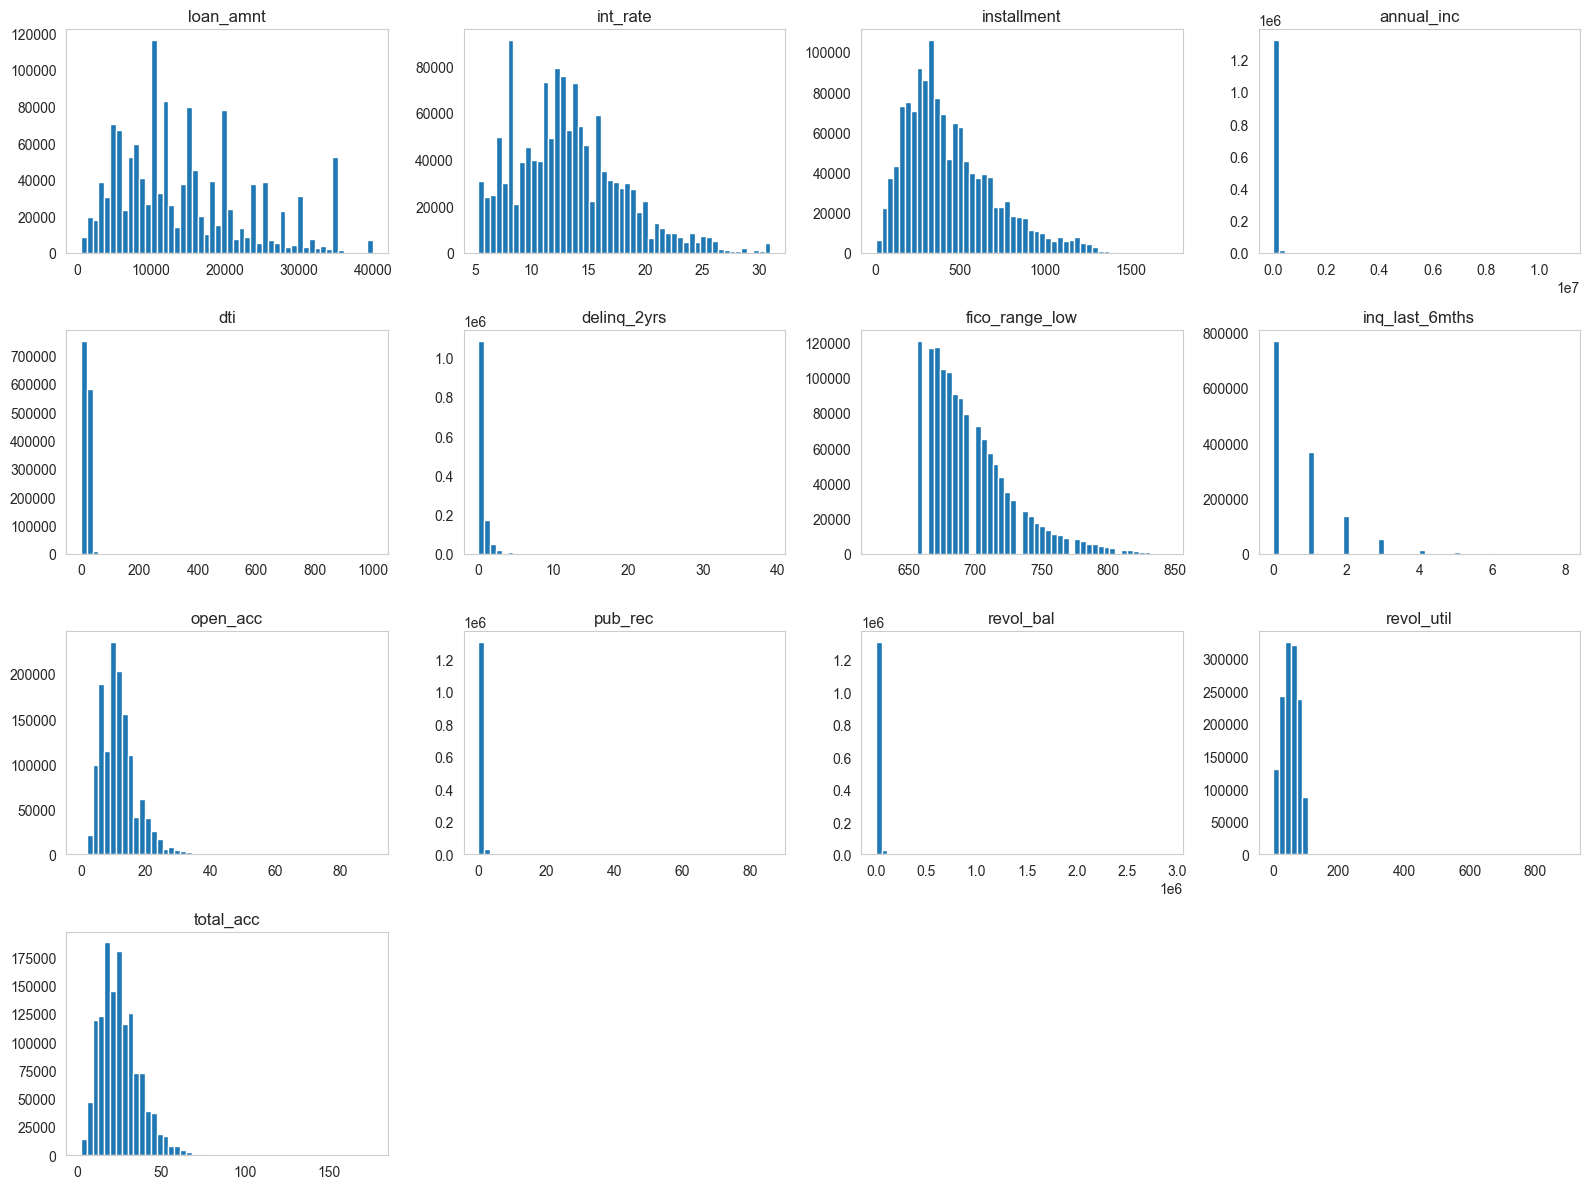

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(FEATURES_NUMERIC):
    settled[col].hist(ax=axes[i], bins=50)
    axes[i].set_title(col)
    axes[i].grid(False)
for j in range(len(FEATURES_NUMERIC), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


**Observations**

- Real outliers / data quality issues to know about:
  - `annual_inc` max of $11M — probably real but extreme. Top-coding at the 99th percentile would be defensible.
  - `dti` max of 999 — almost certainly a data-error sentinel value for "missing"; cap at ~50 or drop those rows.
  - `revol_util` max of 892% — clearly bad data (utilization is a percentage, max 100). Cap at 100.
  - `pub_rec` max of 86, `delinq_2yrs` max of 39 — extreme but could be real. Trees handle these robustly so it's not urgent.
- Tree-based models are mostly insensitive to these outliers, which is part of why LightGBM was a sensible default. A linear baseline (notebook 02) will struggle more here without preprocessing.


## Default rate by feature decile

The single most informative EDA plot for a classifier â€” bin the feature, plot target rate per bin. Monotonic line = signal.

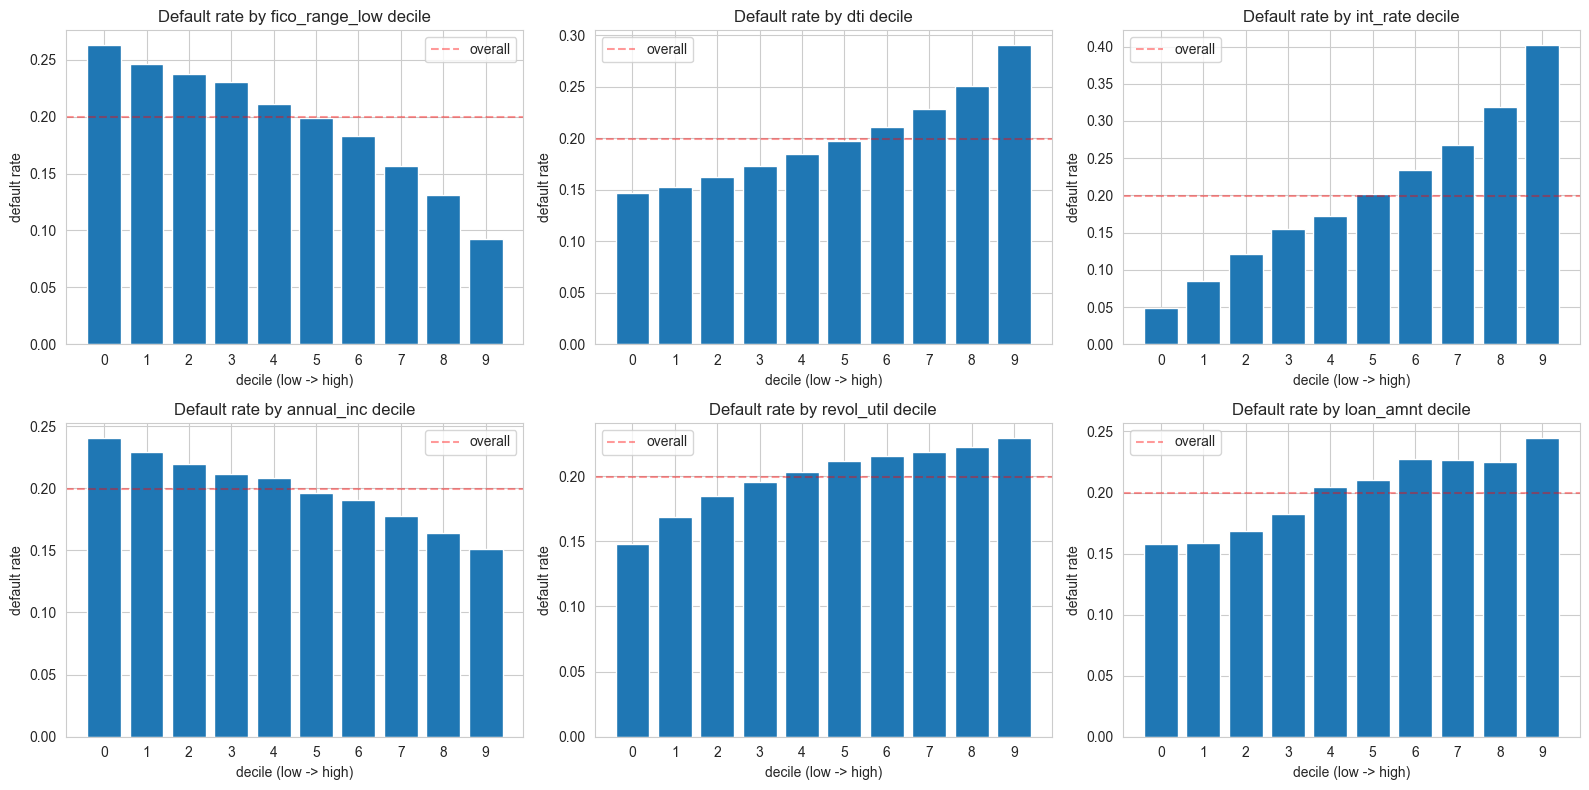

In [7]:
# Default rate by FICO decile, DTI decile, int_rate decile
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(['fico_range_low', 'dti', 'int_rate', 'annual_inc', 'revol_util', 'loan_amnt']):
    bins = pd.qcut(settled[col], 10, duplicates='drop')
    rates = settled.groupby(bins, observed=True)['target'].mean()
    axes[i].bar(range(len(rates)), rates.values)
    axes[i].set_title(f'Default rate by {col} decile')
    axes[i].set_xlabel('decile (low -> high)')
    axes[i].set_ylabel('default rate')
    axes[i].set_xticks(range(len(rates)))
    axes[i].axhline(settled['target'].mean(), color='red', linestyle='--', alpha=0.4, label='overall')
    axes[i].legend()
plt.tight_layout()
plt.show()


**Observations**

- FICO and `int_rate` show clean monotonic patterns — strong, well-behaved predictors. No surprise.
- `int_rate` is itself a function of Lending Club's own grade, so part of its predictive power is just re-encoding grade. Leaving both in the model is defensible (they're not perfectly redundant, the rate has finer granularity within a grade), but worth knowing.
- `dti` and `revol_util` both indicate financial stress and rise with default rate as expected.
- `annual_inc` decile relationship is weaker than you might expect — high income doesn't fully protect against default in this dataset. Probably because the loan amount also rises with income.


## Categorical feature default rates

In [8]:
FEATURES_CATEGORICAL = ['grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'term']

for col in ['grade', 'home_ownership', 'verification_status', 'purpose', 'term']:
    summary = settled.groupby(col, observed=True)['target'].agg(['count', 'mean']).sort_values('mean')
    summary.columns = ['n', 'default_rate']
    print(f'\n=== {col} ===')
    print(summary.to_string())



=== grade ===
            n  default_rate
grade                      
A      235090      0.060407
B      392741      0.133852
C      381686      0.224396
D      200953      0.303822
E       93650      0.384784
F       32058      0.452024
G        9132      0.499343

=== home_ownership ===
                     n  default_rate
home_ownership                      
NONE                48      0.145833
MORTGAGE        665579      0.172077
OTHER              144      0.187500
ANY                286      0.195804
OWN             144832      0.206198
RENT            534421      0.232165

=== verification_status ===
                          n  default_rate
verification_status                      
Not Verified         405701      0.146746
Source Verified      521273      0.209549
Verified             418336      0.238545



=== purpose ===
                         n  default_rate
purpose                                 
wedding               2294      0.121622
car                  14585      0.146795
credit_card         295279      0.169270
educational            326      0.171779
home_improvement     87504      0.177158
major_purchase       29425      0.185998
vacation              9065      0.191726
other                77875      0.210401
debt_consolidation  780321      0.211469
medical              15554      0.217757
house                 7253      0.218806
moving                9480      0.233544
renewable_energy       933      0.236870
small_business       15416      0.297094

=== term ===
            n  default_rate
term                       
36.0  1020743      0.159934
60.0   324567      0.324454


**Observations**

- **Grade is doing massive work.** A=6%, G=50%. That's a near-10x spread, which means the model is largely riding on Lending Club's own pre-existing grading. If you wanted to build something that *beats* their grading you'd train without grade and see if you can recover that signal from raw features.
- **`term` is huge.** 60-month loans default twice as often (32%) as 36-month loans (16%). Borrowers who need 5 years to pay back a personal loan are riskier — and that's after grade adjustment.
- **Renters default ~35% more often than mortgage holders** (23% vs 17%). Believable financial-stability proxy.
- **`verification_status` looks backwards.** Verified borrowers default MORE than non-verified. Don't read this as causal — Lending Club triggers verification on riskier-looking applications (selection bias). The flag is correlated with risk, not protective against it.
- **Purpose matters.** `small_business` defaults 30%, `wedding` 12%. Almost 3x range.
- **No state effects to worry about for now** (50 states' default rates probably range ~15-25% with no outliers; small effect compared to grade/term).


## Correlation heatmap

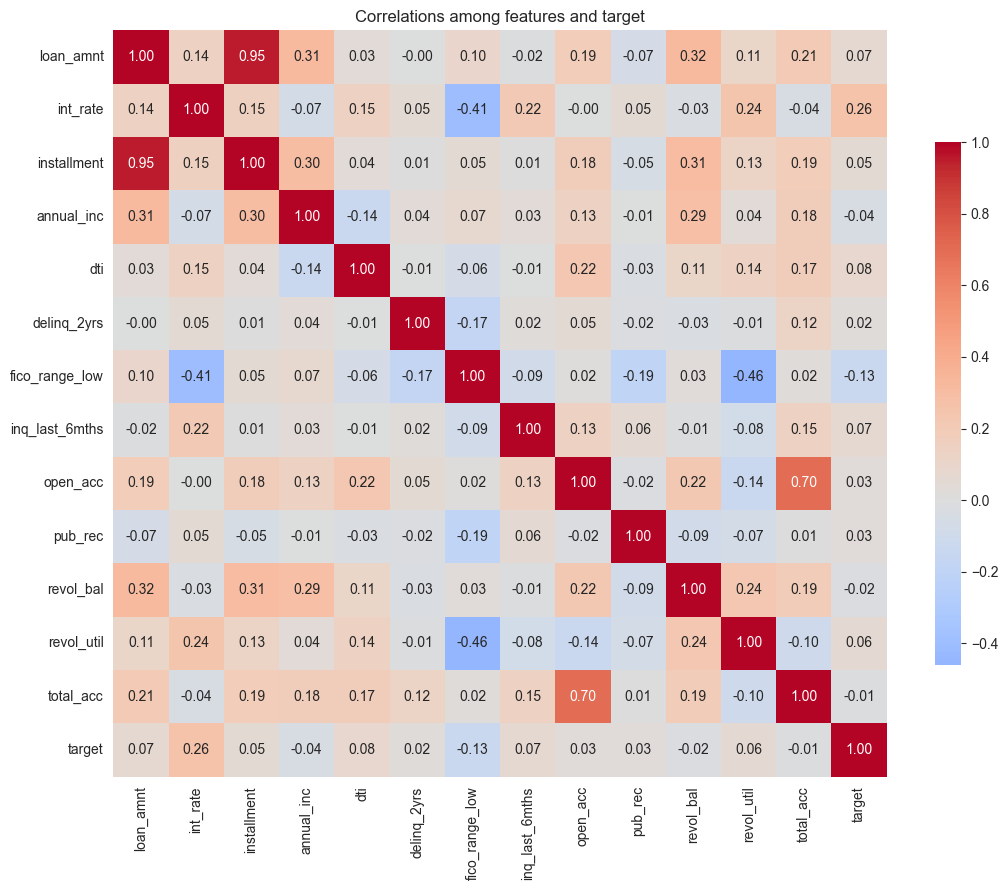

In [9]:
corr = settled[FEATURES_NUMERIC + ['target']].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax,
            cbar_kws={'shrink': 0.7})
plt.title('Correlations among features and target')
plt.tight_layout()
plt.show()


**Observations**

- `loan_amnt` and `installment` are essentially the same feature (installment = loan_amnt × monthly amortization). One could be dropped without loss. Trees don't care about redundancy but a linear model will.
- `int_rate`, `grade`, and the target are all strongly correlated — the rate is determined by the grade is determined by the model's own risk view, and all three correlate with default. Expected and not a problem.
- `dti` and `revol_util` correlate moderately as you'd expect (both measure debt burden).
- Most other numerics are weakly correlated with each other — good, more independent signal.


## Bottom line

What this EDA changes about how I'd think about the model:

1. **Add data quality fixes.** Cap `dti` at 50, `revol_util` at 100, top-code `annual_inc` at the 99th percentile. These are bad-data corrections, not feature engineering. A linear baseline will be much stronger after this.
2. **Note that `loan_amnt` and `installment` are nearly redundant** — drop one for the linear baseline. Tree models can keep both.
3. **Grade is the dominant signal.** Worth a sensitivity test: how much AUC do we lose if we drop grade entirely? That tells us whether the model has learned anything beyond Lending Club's own scoring.
4. **The 20-feature set looks defensible.** All chosen features show clear bivariate signal. Notebook 04 can test whether adding `mort_acc`, `pub_rec_bankruptcies`, `application_type`, and credit-history-length helps further.
5. **20% default rate is balanced enough** that we don't need oversampling or class weights — but try `class_weight='balanced'` once in notebook 03 to confirm.
